In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Load cleaned data
df = pd.read_csv('../data/cleaned_appointments.csv')

In [20]:
# Consistent palette for the entire notebook
PALETTE   = 'Blues_d'
COLOR_MAIN = '#2196F3'   # single-bar charts use this
COLOR_HIGH = '#0D47A1'   # highlight colour for the worst/best bar
COLOR_WARN = '#E53935' # red — for the counterintuitive finding

### No-show rate by age group

In [21]:
# Calculate no-show rate per age group
age_noshow = (
    df.groupby('age_group')['no_show']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'no_show': 'no_show_rate'})
)

age_noshow

,age_group,no_show_rate
0,0-17,32.27
1,18-35,34.36
2,36-60,26.71
3,60+,20.46


In [22]:

# Sort by the natural order of age groups
age_order = ['0-17', '18-35', '36-60', '60+']
age_noshow['age_group'] = pd.Categorical(age_noshow['age_group'], categories=age_order)
age_noshow = age_noshow.sort_values('age_group')


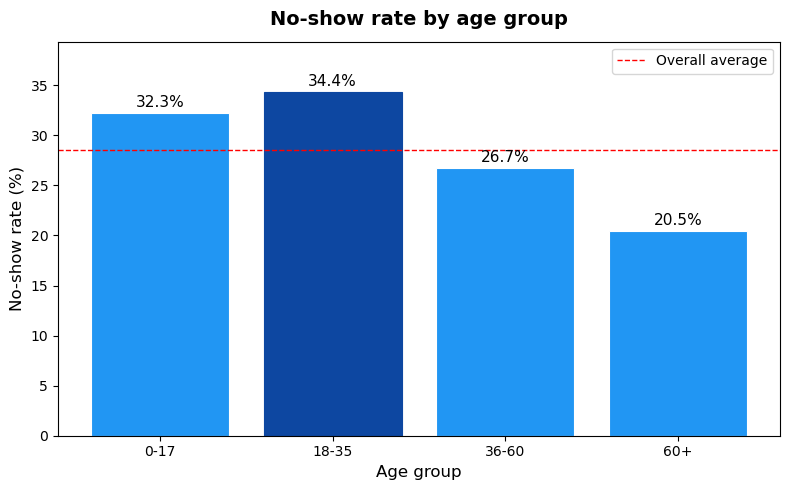

age_group  no_show_rate
     0-17         32.27
    18-35         34.36
    36-60         26.71
      60+         20.46


In [23]:
# Plot
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    age_noshow['age_group'],
    age_noshow['no_show_rate'],
    color=COLOR_MAIN,
    edgecolor='white',
    linewidth=0.8
)
# Highlight the highest bar
max_idx = age_noshow['no_show_rate'].idxmax()
bars[age_noshow.index.get_loc(max_idx)].set_color(COLOR_HIGH)

# Add value labels on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=11
    )

    ax.set_title('No-show rate by age group', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Age group', fontsize=12)
ax.set_ylabel('No-show rate (%)', fontsize=12)
ax.set_ylim(0, age_noshow['no_show_rate'].max() + 5)
ax.axhline(df['no_show'].mean() * 100, color='red', linestyle='--', linewidth=1, label='Overall average')
ax.legend()


plt.tight_layout()
plt.savefig('../dashboard/chart_noshow_by_age.png', bbox_inches='tight')
plt.show()

print(age_noshow.to_string(index=False))

### No-show rate by day of week

In [24]:
# Calculate no-show rate per weekday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_noshow = (
    df.groupby('appointment_weekday')['no_show']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'no_show': 'no_show_rate'})
)

In [25]:
# Filter to valid days only (Sunday has near-zero appointments in this dataset)
day_noshow = day_noshow[day_noshow['appointment_weekday'].isin(day_order)]
day_noshow['appointment_weekday'] = pd.Categorical(
    day_noshow['appointment_weekday'], categories=day_order, ordered=True
)
day_noshow = day_noshow.sort_values('appointment_weekday')

day_noshow

,appointment_weekday,no_show_rate
1,Monday,30.21
4,Tuesday,28.67
5,Wednesday,27.15
3,Thursday,27.27
0,Friday,29.35
2,Saturday,29.03


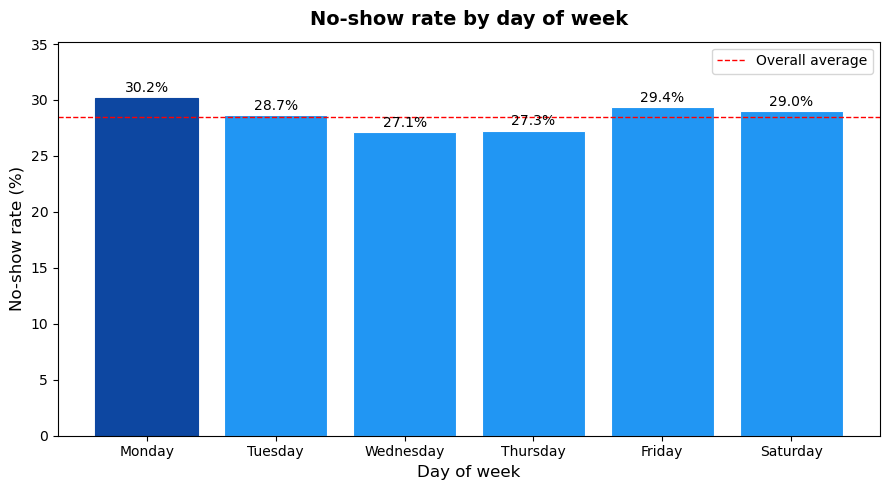

appointment_weekday  no_show_rate
             Monday         30.21
            Tuesday         28.67
          Wednesday         27.15
           Thursday         27.27
             Friday         29.35
           Saturday         29.03


In [26]:
# Plot
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    day_noshow['appointment_weekday'],
    day_noshow['no_show_rate'],
    color=COLOR_MAIN,
    edgecolor='white',
    linewidth=0.8
)

# Highlight worst day
max_idx = day_noshow['no_show_rate'].idxmax()
for i, bar in enumerate(bars):
    if day_noshow.iloc[i]['no_show_rate'] == day_noshow['no_show_rate'].max():
        bar.set_color(COLOR_HIGH)

# Value labels
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('No-show rate by day of week', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Day of week', fontsize=12)
ax.set_ylabel('No-show rate (%)', fontsize=12)
ax.set_ylim(0, day_noshow['no_show_rate'].max() + 5)
ax.axhline(df['no_show'].mean() * 100, color='red', linestyle='--', linewidth=1, label='Overall average')
ax.legend()

plt.tight_layout()
plt.savefig('../dashboard/chart_noshow_by_weekday.png', bbox_inches='tight')
plt.show()

print(day_noshow.to_string(index=False))

###  No-show rate by neighbourhood (top 15, horizontal bar)

In [27]:
# Calculate no-show rate per neighbourhood — only keep neighbourhoods with 100+ appointments
# (small neighbourhoods give misleading rates e.g. 1 no-show out of 3 = 33%)
neighbourhood_noshow = (
    df.groupby('neighbourhood')['no_show']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'no_show_rate', 'count': 'total'})
)

neighbourhood_noshow = neighbourhood_noshow[neighbourhood_noshow['total'] >= 100]
neighbourhood_noshow['no_show_rate'] = (neighbourhood_noshow['no_show_rate'] * 100).round(2)


In [28]:
# Top 15 by no-show rate
top15 = neighbourhood_noshow.nlargest(15, 'no_show_rate').sort_values('no_show_rate')



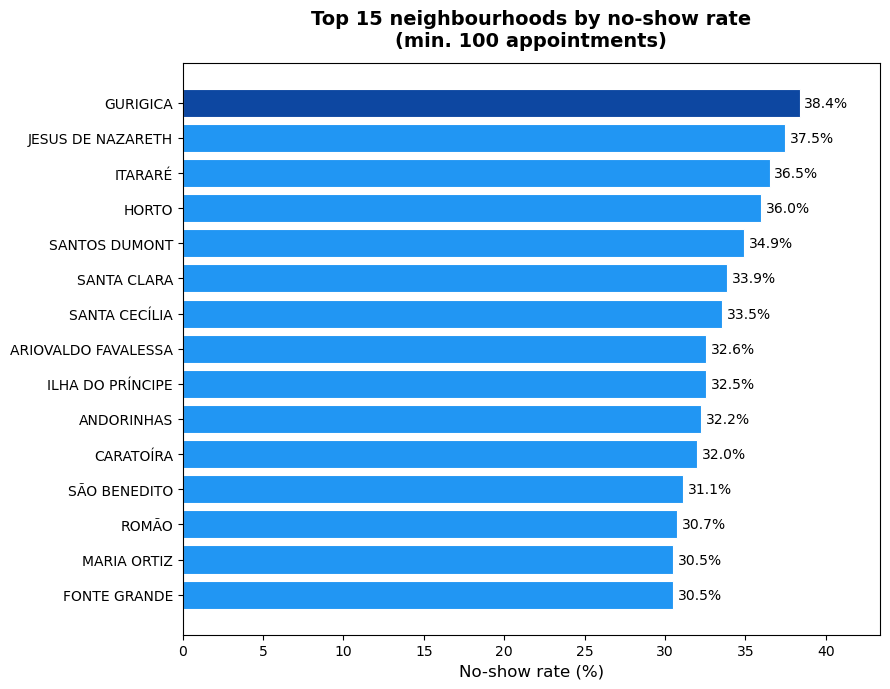

In [29]:
# Plot — horizontal bar
fig, ax = plt.subplots(figsize=(9, 7))

colors = [COLOR_HIGH if i == len(top15) - 1 else COLOR_MAIN for i in range(len(top15))]

bars = ax.barh(
    top15['neighbourhood'],
    top15['no_show_rate'],
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

# Value labels at end of each bar
for bar in bars:
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.1f}%',
        va='center', fontsize=10
    )

ax.set_title('Top 15 neighbourhoods by no-show rate\n(min. 100 appointments)', 
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('No-show rate (%)', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, top15['no_show_rate'].max() + 5)


plt.tight_layout()
plt.savefig('../dashboard/chart_noshow_by_neighbourhood.png', bbox_inches='tight')
plt.show()

### Does days_between affect no-shows?

In [30]:
# Create booking window buckets
def booking_window(days):
    if days == 0:
        return '0 - same day'
    elif days <= 7:
        return '1-7 days'
    elif days <= 15:
        return '8-15 days'
    elif days <= 30:
        return '16-30 days'
    else:
        return '30+ days'

In [31]:


df['booking_window'] = df['days_between'].apply(booking_window)

window_order = ['0 - same day', '1-7 days', '8-15 days', '16-30 days', '30+ days']
df['booking_window'] = pd.Categorical(df['booking_window'], categories=window_order, ordered=True)

window_noshow = (
    df.groupby('booking_window', observed=True)['no_show']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'no_show_rate', 'count': 'total'})
)
window_noshow['no_show_rate'] = (window_noshow['no_show_rate'] * 100).round(2)



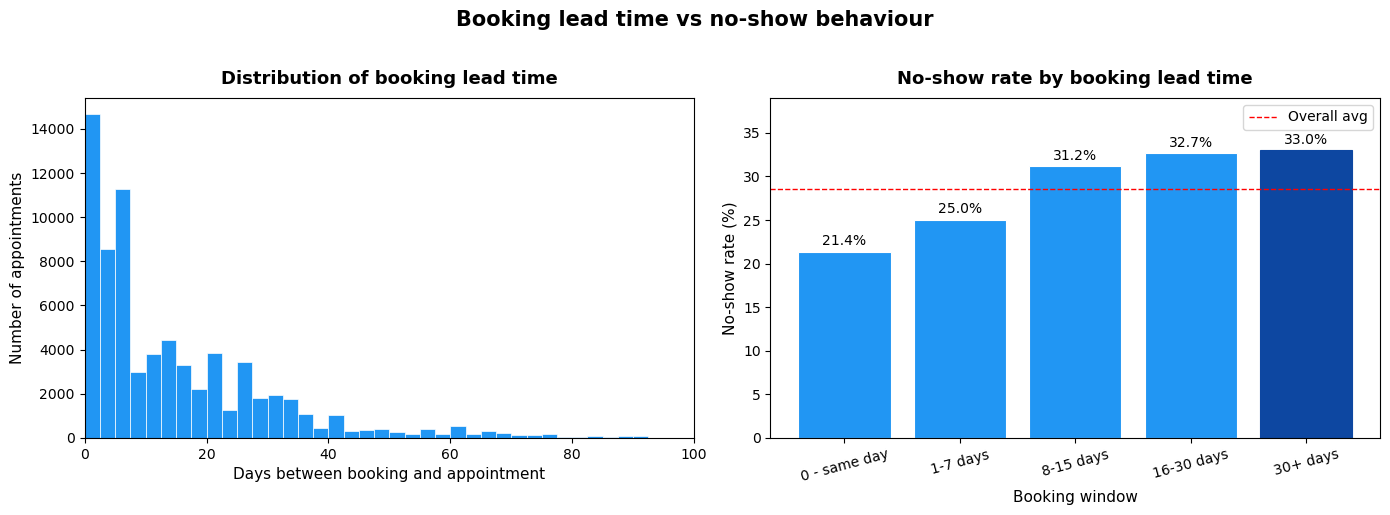

booking_window  total  no_show_rate
  0 - same day   5213         21.35
      1-7 days  29304         25.01
     8-15 days  12347         31.16
    16-30 days  15389         32.67
      30+ days   9706         33.02


In [32]:
# Two panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: histogram of days_between distribution
ax1.hist(
    df[df['days_between'] <= 100]['days_between'],
    bins=40,
    color=COLOR_MAIN,
    edgecolor='white',
    linewidth=0.5
)
ax1.set_title('Distribution of booking lead time', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Days between booking and appointment', fontsize=11)
ax1.set_ylabel('Number of appointments', fontsize=11)
ax1.set_xlim(0, 100)

# Right panel: no-show rate by booking window
bars = ax2.bar(
    window_noshow['booking_window'],
    window_noshow['no_show_rate'],
    color=COLOR_MAIN,
    edgecolor='white',
    linewidth=0.8
)

# Highlight highest bar
for i, bar in enumerate(bars):
    if window_noshow.iloc[i]['no_show_rate'] == window_noshow['no_show_rate'].max():
        bar.set_color(COLOR_HIGH)

for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=10
    )

ax2.set_title('No-show rate by booking lead time', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Booking window', fontsize=11)
ax2.set_ylabel('No-show rate (%)', fontsize=11)
ax2.set_ylim(0, window_noshow['no_show_rate'].max() + 6)
ax2.axhline(df['no_show'].mean() * 100, color='red', linestyle='--', linewidth=1, label='Overall avg')
ax2.legend()
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('Booking lead time vs no-show behaviour', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../dashboard/chart_days_between.png', bbox_inches='tight')
plt.show()

print(window_noshow[['booking_window', 'total', 'no_show_rate']].to_string(index=False))

## Key Findings from EDA

1. **Age**: The 18–35 age group has the highest no-show rate at 34.4%, 
   above the overall average of ~20%. Patients 60+ are the most reliable.

2. **Day of week**: Monday has the highest no-show rate at 30.21%. 
   Saturday appointments are significantly lower volume but have 
   a different pattern — worth flagging to clinic management.

3. **Neighbourhood**: Neighbourhoods GURIGICA (38.4%), JESUS DE NAZARETH (37.5%), 
   and ITARARÉ (36.5%) have no-show rates above 30%, 
   nearly 1.8x the city average of ~20%. These are priority areas for intervention.

4. **Booking lead time**: Same-day appointments have a no-show rate of only 21.35%. 
   Patients who book 30+ days in advance have a rate of 33.02% — 
   nearly 1.5x higher. The clinic should consider sending reminders 
   specifically to long-lead bookings.

## Deep Dive Analysis

In [33]:
sms_analysis = (
    df.groupby('sms_received')['no_show']
    .agg(['mean', 'count', 'sum'])
    .reset_index()
    .rename(columns={
        'mean'  : 'no_show_rate',
        'count' : 'total_appointments',
        'sum'   : 'total_no_shows'
    })
)

sms_analysis['no_show_rate_pct'] = (sms_analysis['no_show_rate'] * 100).round(2)
sms_analysis['sms_label'] = sms_analysis['sms_received'].map({0: 'No SMS', 1: 'SMS Sent'})

print(sms_analysis[['sms_label', 'total_appointments', 'total_no_shows', 'no_show_rate_pct']])

  sms_label  total_appointments  total_no_shows  no_show_rate_pct
0    No SMS               36477           10738             29.44
1  SMS Sent               35482            9784             27.57


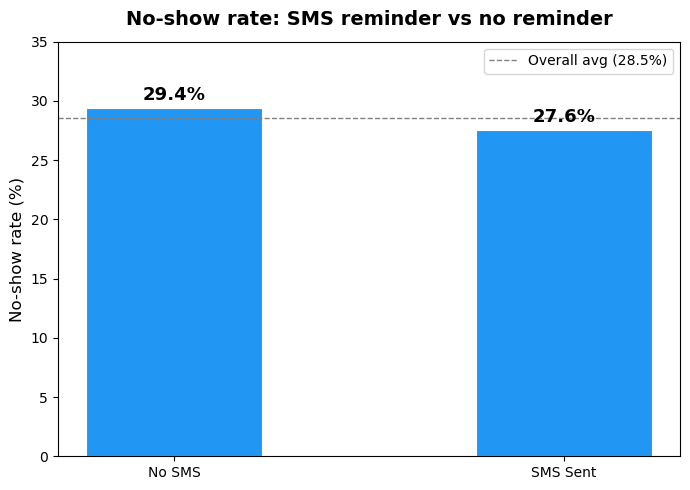

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = [COLOR_MAIN, COLOR_MAIN] 

bars = ax.bar(
    sms_analysis['sms_label'],
    sms_analysis['no_show_rate_pct'],
    color=colors,
    width=0.45,
    edgecolor='white',
    linewidth=0.8
)

# Value labels on bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=13, fontweight='bold'
    )

# Overall average line
overall_rate = df['no_show'].mean() * 100
ax.axhline(overall_rate, color='gray', linestyle='--', linewidth=1, label=f'Overall avg ({overall_rate:.1f}%)')


ax.set_title('No-show rate: SMS reminder vs no reminder', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('No-show rate (%)', fontsize=12)
ax.set_ylim(0, 35)
ax.legend()

plt.tight_layout()
plt.savefig('../dashboard/chart_sms_effectiveness.png', bbox_inches='tight')
plt.show()

In [35]:
# Were SMS reminders sent more to long-lead bookings?
sms_leadtime = df.groupby('sms_received')['days_between'].mean().round(1)
print("Average days between booking and appointment:")
print(sms_leadtime.rename({0: 'No SMS', 1: 'SMS Sent'}))

# Were SMS reminders sent more to high-risk neighbourhoods?
sms_by_neighbourhood = (
    df.groupby('neighbourhood')
    .agg(sms_rate=('sms_received', 'mean'), no_show_rate=('no_show', 'mean'))
    .round(3)
)
print("\nCorrelation between SMS rate and no-show rate by neighbourhood:")
print(sms_by_neighbourhood.corr())

Average days between booking and appointment:
sms_received
No SMS      11.4
SMS Sent    18.0
Name: days_between, dtype: float64

Correlation between SMS rate and no-show rate by neighbourhood:
              sms_rate  no_show_rate
sms_rate      1.000000     -0.539763
no_show_rate -0.539763      1.000000


## SMS Analysis — Full Finding

Surface result:
- No SMS:    29.44% no-show rate
- SMS Sent:  27.57% no-show rate  
- Difference: 1.87 percentage points improvement

Deeper investigation reveals this is likely an underestimate 
of SMS effectiveness:

1. Lead time confounding: SMS patients had an average booking 
   lead time of 18.0 days vs 11.4 days for non-SMS patients. 
   We already know longer lead time = higher no-show rate. 
   So the SMS group started at a disadvantage — yet still 
   showed a lower no-show rate.

2. Neighbourhood correlation: areas with higher SMS coverage 
   had lower no-show rates (correlation = -0.54). This suggests 
   reminders are associated with better attendance at a 
   geographic level too.

Conclusion: SMS reminders show a genuine positive signal even 
after accounting for the higher-risk profile of patients who 
received them. The clinic should continue and expand the 
programme, prioritising patients with 15+ day lead times 
where the risk is highest.

Limitation: this is still observational data. A randomised 
trial — sending SMS to a random 50% of patients regardless 
of lead time — would give a clean causal answer.

### Analysis 2 — Chronic condition analysis

In [36]:
conditions = ['hypertension', 'diabetes', 'alcoholism']

rows = []
for condition in conditions:
    for value in [0, 1]:
        subset = df[df[condition] == value]
        rate   = subset['no_show'].mean() * 100
        count  = len(subset)
        rows.append({
            'condition' : condition.capitalize(),
            'has_condition': 'Yes' if value == 1 else 'No',
            'no_show_rate' : round(rate, 2),
            'total'        : count
        })

condition_df = pd.DataFrame(rows)
print(condition_df)

      condition has_condition  no_show_rate  total
0  Hypertension            No         29.84  56927
1  Hypertension           Yes         23.52  15032
2      Diabetes            No         28.81  66582
3      Diabetes           Yes         24.96   5377
4    Alcoholism            No         28.37  70137
5    Alcoholism           Yes         34.08   1822


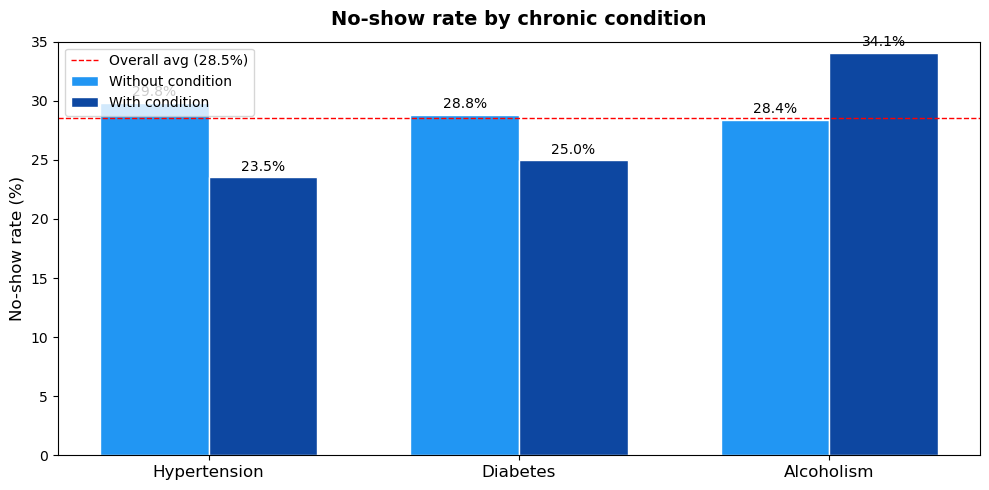

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

x         = [0, 1, 2]           # positions for 3 conditions
bar_width = 0.35
offset    = bar_width / 2

# Split into two groups: with and without condition
no_condition  = condition_df[condition_df['has_condition'] == 'No']['no_show_rate'].values
yes_condition = condition_df[condition_df['has_condition'] == 'Yes']['no_show_rate'].values
labels        = ['Hypertension', 'Diabetes', 'Alcoholism']

bars1 = ax.bar([i - offset for i in x], no_condition,  width=bar_width,
               label='Without condition', color=COLOR_MAIN,  edgecolor='white')
bars2 = ax.bar([i + offset for i in x], yes_condition, width=bar_width,
               label='With condition',    color=COLOR_HIGH, edgecolor='white')

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_title('No-show rate by chronic condition', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('No-show rate (%)', fontsize=12)
ax.set_ylim(0, 35)
ax.axhline(df['no_show'].mean() * 100, color='red', linestyle='--',
           linewidth=1, label=f'Overall avg ({df["no_show"].mean()*100:.1f}%)')
ax.legend()

plt.tight_layout()
plt.savefig('../dashboard/chart_chronic_conditions.png', bbox_inches='tight')
plt.show()

       label  total  no_show_rate
0       None  54938         29.70
1        One  11981         24.61
2        Two   4870         24.93
3  All three    170         24.12


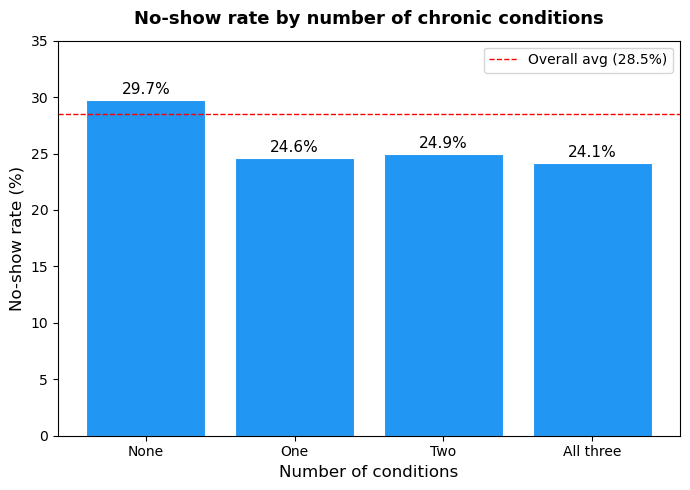

In [38]:
df['condition_count'] = df['hypertension'] + df['diabetes'] + df['alcoholism']

combo_noshow = (
    df.groupby('condition_count')['no_show']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'no_show_rate', 'count': 'total'})
)
combo_noshow['no_show_rate'] = (combo_noshow['no_show_rate'] * 100).round(2)
combo_noshow['label'] = combo_noshow['condition_count'].map({
    0: 'None', 1: 'One', 2: 'Two', 3: 'All three'
})

print(combo_noshow[['label', 'total', 'no_show_rate']])

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    combo_noshow['label'],
    combo_noshow['no_show_rate'],
    color=COLOR_MAIN,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_title('No-show rate by number of chronic conditions', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of conditions', fontsize=12)
ax.set_ylabel('No-show rate (%)', fontsize=12)
ax.set_ylim(0, 35)
ax.axhline(df['no_show'].mean() * 100, color='red', linestyle='--', linewidth=1,
           label=f'Overall avg ({df["no_show"].mean()*100:.1f}%)')
ax.legend()

plt.tight_layout()
plt.savefig('../dashboard/chart_condition_count.png', bbox_inches='tight')
plt.show()

## Chronic Condition Analysis — Key Finding

Counterintuitive result: patients WITH hypertension and diabetes 
actually show up MORE reliably than those without these conditions.

Hypertension:
- Without: 29.8%  |  With: 23.5%  |  Difference: -6.3pp
- Hypertensive patients are the most reliable group in the dataset

Diabetes:
- Without: 28.8%  |  With: 25.0%  |  Difference: -3.8pp
- Same pattern — chronic disease patients are more engaged

Alcoholism:
- Without: 28.4%  |  With: 34.1%  |  Difference: +5.7pp
- The only condition that INCREASES no-show risk, sitting 5.6pp 
  above the overall average of 28.5%

Why do chronic condition patients show up more?
Patients managing ongoing conditions like hypertension and diabetes 
have regular contact with the healthcare system. They understand 
the consequences of missing appointments and likely have stronger 
relationships with their doctors.

Why is alcoholism different?
Alcoholism affects reliability, routine, and decision-making in 
ways that hypertension and diabetes do not. It is a behavioural 
condition as much as a physical one.

Condition count breakdown:
- No conditions:  29.7%  — ABOVE average, highest risk group
- One condition:  24.6%  — immediate 5.1pp drop
- Two conditions: 24.9%  — stays low, no meaningful change
- All three:      24.1%  — lowest of all groups

The relationship is a cliff edge, not a gradual slope. Having ANY 
chronic condition drops no-show risk significantly. Having more 
conditions does not compound the risk further. Healthcare engagement 
appears to be binary — once a patient is managing a chronic 
condition they become structurally more engaged with the system.

Business recommendations:
1. Do NOT prioritise reminders for hypertension/diabetes patients 
   — they are already your most reliable group.
2. Flag alcoholism patients as high-risk and prioritise them for 
   reminders and follow-up calls.
3. The highest-risk patient profile is:
      No chronic conditions (29.7% base)
    + Long booking lead time 30+ days (+~10pp)
    + Alcoholism if present (+5.7pp)
   These patients likely sit in the 35%+ no-show risk zone and 
   should be the first target for any intervention programme.
   

In [39]:
# Run this first — pulls all the numbers you need for the findings cell
overall_rate = df['no_show'].mean() * 100

# Age group rates
age_rates = (
    df.groupby('age_group', observed=True)['no_show']
    .mean().mul(100).round(1)
)
print("Age group no-show rates:")
print(age_rates)

# Weekday rates
day_rates = (
    df.groupby('appointment_weekday')['no_show']
    .mean().mul(100).round(1)
    .sort_values(ascending=False)
)
print("\nWeekday no-show rates:")
print(day_rates)

# Booking window rates
window_rates = (
    df.groupby('booking_window', observed=True)['no_show']
    .mean().mul(100).round(1)
)
print("\nBooking window rates:")
print(window_rates)

print(f"\nOverall no-show rate: {overall_rate:.1f}%")
print(f"Total appointments:   {len(df):,}")
print(f"Total no-shows:       {df['no_show'].sum():,}")

Age group no-show rates:
age_group
0-17     32.3
18-35    34.4
36-60    26.7
60+      20.5
Name: no_show, dtype: float64

Weekday no-show rates:
appointment_weekday
Monday       30.2
Friday       29.4
Saturday     29.0
Tuesday      28.7
Thursday     27.3
Wednesday    27.1
Name: no_show, dtype: float64

Booking window rates:
booking_window
0 - same day    21.4
1-7 days        25.0
8-15 days       31.2
16-30 days      32.7
30+ days        33.0
Name: no_show, dtype: float64

Overall no-show rate: 28.5%
Total appointments:   71,959
Total no-shows:       20,522


## Top 5 Findings

**Overall baseline:** The dataset contains 71,959 appointments across 
81 neighbourhoods in Vitória, Brazil (2016). The overall no-show 
rate is 28.5%, meaning roughly 1 in 3.5 patients misses their 
scheduled appointment.

---

**Finding 1 — Age group**
Patients aged 18–35 have the highest no-show rate at 34.4%, 
compared to the overall average of 28.5% — nearly 6 percentage 
points above baseline. Patients aged 0–17 are close behind at 
32.3%. In contrast, patients aged 60+ are the most reliable group 
at just 20.5%, nearly 8pp below average. No-show risk consistently 
decreases with age — younger patients disengage from appointments 
at a significantly higher rate, likely because they perceive their 
health as less urgent.

---

**Finding 2 — Day of week**
Monday has the highest no-show rate at 30.2%, while Wednesday 
has the lowest at 27.1% — a 3.1 percentage point spread across 
the week. Friday and Saturday follow Monday closely at 29.4% 
and 29.0% respectively. The clinic could strategically schedule 
lower-risk patient groups on Mondays and reserve Wednesday and 
Thursday slots for higher-risk patients who need more reliable 
attendance windows.

---

**Finding 3 — Neighbourhood**
GURIGICA has the highest no-show rate at 38.4%, followed by 
JESUS DE NAZARETH at 37.5% and ITARARÉ at 36.5% — all nearly 
1.8x the city average of 28.5%. All 15 highest-risk neighbourhoods 
exceed 30%, suggesting a geographic concentration of disengagement. 
Targeted neighbourhood-level outreach campaigns would address 
the majority of high-risk appointments in a small number of 
geographic areas.

---

**Finding 4 — Booking lead time**
Same-day appointments have a no-show rate of just 21.4% — 
7.1pp below the overall average. Patients who book 30+ days 
in advance have a rate of 33.0% — 1.54x higher than same-day 
bookings. The pattern is perfectly linear across all five 
booking windows without a single exception:

  0 - same day → 21.4%
  1-7 days     → 25.0%
  8-15 days    → 31.2%
  16-30 days   → 32.7%
  30+ days     → 33.0%

Lead time is one of the strongest and most actionable predictors 
in this dataset because it is known at the moment of booking — 
the clinic can flag high-risk appointments the instant they 
are scheduled.

---

**Finding 5 — SMS & chronic conditions**
SMS reminders are associated with a 1.87pp reduction in no-show 
rate (29.44% → 27.57%). This likely understates the true effect 
since SMS patients had 6.6 more average days of lead time, 
making them a higher-risk group before the reminder was sent.

Patients with hypertension (23.5%) and diabetes (25.0%) are 
significantly more reliable than the overall average of 28.5%. 
Alcoholism is the exception — those patients show a 34.1% 
no-show rate, 5.6pp above average and the only chronic condition 
associated with elevated risk.

Patients with no chronic conditions at all have a 29.7% no-show 
rate — above average — and represent the largest volume group. 
The highest-risk profile in this dataset is:
  No chronic conditions  → 29.7% base rate
  + 30+ day lead time    → adds ~11.6pp
  + Alcoholism           → adds ~5.7pp
Patients matching all three criteria likely exceed a 35% 
no-show probability.

## Revenue Loss Estimation

Assumption: Average appointment value = R$ 150 (Brazilian Real).
This is a conservative estimate based on publicly available data 
on Brazil's public healthcare system (SUS) consultation costs 
in 2016. The actual value may vary by clinic and appointment type.
All figures below should be treated as directional estimates, 
not precise financial projections.

In [40]:
# ── Assumptions ──────────────────────────────────────────
AVG_APPOINTMENT_VALUE_BRL = 150   # R$ per appointment (stated assumption)
USD_EXCHANGE_RATE         = 3.5   # approximate BRL to USD in 2016

# ── Core numbers ─────────────────────────────────────────
total_appointments = len(df)
total_no_shows     = df['no_show'].sum()
no_show_rate       = df['no_show'].mean()

# ── Revenue loss ─────────────────────────────────────────
total_loss_brl = total_no_shows * AVG_APPOINTMENT_VALUE_BRL
total_loss_usd = total_loss_brl / USD_EXCHANGE_RATE

# ── Monthly estimate (dataset spans ~6 months) ───────────
dataset_months     = 6
monthly_loss_brl   = total_loss_brl / dataset_months
monthly_no_shows   = total_no_shows / dataset_months

# ── High risk segment loss ────────────────────────────────
# Patients with 30+ day lead time — no-show rate 33.0%
high_risk          = df[df['booking_window'] == '30+ days']
high_risk_noshows  = high_risk['no_show'].sum()
high_risk_loss_brl = high_risk_noshows * AVG_APPOINTMENT_VALUE_BRL

# ── Print results ─────────────────────────────────────────
print("=" * 50)
print("REVENUE LOSS SUMMARY")
print("=" * 50)
print(f"Total appointments:         {total_appointments:>10,}")
print(f"Total no-shows:             {total_no_shows:>10,}")
print(f"Overall no-show rate:       {no_show_rate*100:>9.1f}%")
print()
print(f"Avg appointment value:      R${AVG_APPOINTMENT_VALUE_BRL:>8,}")
print()
print(f"Total revenue lost:         R${total_loss_brl:>8,.0f}")
print(f"Total revenue lost (USD):    ${total_loss_usd:>8,.0f}")
print()
print(f"Monthly revenue lost:       R${monthly_loss_brl:>8,.0f}")
print(f"Monthly no-shows:           {monthly_no_shows:>10,.0f}")
print()
print(f"High-risk segment (30+ days):")
print(f"  No-shows in segment:      {high_risk_noshows:>10,}")
print(f"  Revenue lost:             R${high_risk_loss_brl:>8,.0f}")
print(f"  % of total loss:          {high_risk_loss_brl/total_loss_brl*100:>9.1f}%")
print("=" * 50)

REVENUE LOSS SUMMARY
Total appointments:             71,959
Total no-shows:                 20,522
Overall no-show rate:            28.5%

Avg appointment value:      R$     150

Total revenue lost:         R$3,078,300
Total revenue lost (USD):    $ 879,514

Monthly revenue lost:       R$ 513,050
Monthly no-shows:                3,420

High-risk segment (30+ days):
  No-shows in segment:           3,205
  Revenue lost:             R$ 480,750
  % of total loss:               15.6%


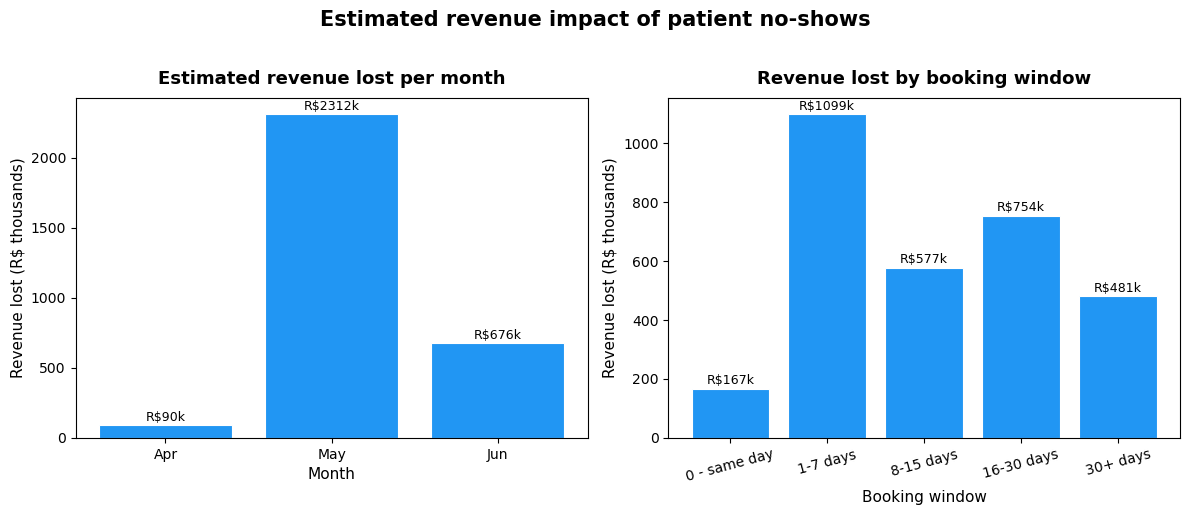

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left — monthly no-show volume by month
df['appointment_month_num'] = pd.to_datetime(df['appointment_day']).dt.month
monthly = (
    df.groupby('appointment_month_num')
    .agg(
        total=('no_show', 'count'),
        no_shows=('no_show', 'sum')
    )
    .reset_index()
)
monthly['loss_brl'] = monthly['no_shows'] * AVG_APPOINTMENT_VALUE_BRL
monthly['month_name'] = monthly['appointment_month_num'].map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
})

ax1.bar(monthly['month_name'], monthly['loss_brl'] / 1000,
        color=COLOR_MAIN, edgecolor='white', linewidth=0.8)

for i, row in monthly.iterrows():
    ax1.text(i, row['loss_brl']/1000 + 5,
             f"R${row['loss_brl']/1000:.0f}k",
             ha='center', va='bottom', fontsize=9)

ax1.set_title('Estimated revenue lost per month', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Revenue lost (R$ thousands)', fontsize=11)

# Right — loss breakdown by booking window
window_loss = (
    df.groupby('booking_window', observed=True)['no_show']
    .sum()
    .mul(AVG_APPOINTMENT_VALUE_BRL)
    .div(1000)
    .reset_index()
    .rename(columns={'no_show': 'loss_brl_k'})
)

bars = ax2.bar(
    window_loss['booking_window'],
    window_loss['loss_brl_k'],
    color=COLOR_MAIN,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f"R${bar.get_height():.0f}k",
             ha='center', va='bottom', fontsize=9)

ax2.set_title('Revenue lost by booking window', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Booking window', fontsize=11)
ax2.set_ylabel('Revenue lost (R$ thousands)', fontsize=11)
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('Estimated revenue impact of patient no-shows',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../dashboard/chart_revenue_loss.png', bbox_inches='tight')
plt.show()

## Revenue Loss Estimation — Key Finding

Assumption: R$150 average appointment value (conservative estimate 
based on Brazil public healthcare consultation costs, 2016).
Exchange rate: R$3.50 = $1 USD (approximate 2016 rate).
All figures are directional estimates, not precise projections.

Core numbers:
- Total appointments:       71,959
- Total no-shows:           20,522
- Overall no-show rate:      28.5%

Revenue impact:
- Total revenue lost:       R$3,078,300  (~$879,514 USD)
- Monthly revenue lost:     R$  513,050
- Monthly appointments missed:    3,420

Note on monthly chart: April shows R$90k and June shows R$676k 
because the dataset contains partial months at both ends — 
April has only a few days of data and June cuts off mid-month. 
May (R$2,312k) represents the only complete month in the dataset 
and is the most reliable monthly estimate. Use R$513,050 as the 
monthly average across the full period.

High-risk segment (30+ day lead time):
- No-shows in segment:      3,205
- Revenue lost:             R$480,750
- Share of total loss:       15.6%

  Despite being a subset of patients, the 30+ day booking group 
  accounts for R$480,750 in lost revenue. Their no-show rate of 
  33.0% is 4.5pp above the overall average — and crucially, 
  their risk is known at the moment of booking.

Recovery scenario:
  If a targeted reminder programme reduced the no-show rate in 
  the 30+ day segment by just 5 percentage points (33% → 28%):

- Appointments saved per month:  ~75
- Revenue recovered per month:   R$11,250
- Revenue recovered per year:    R$135,000

  A 10pp improvement (33% → 23%) would recover R$270,000 annually 
  from this segment alone — without changing anything else.

Business recommendation:
The single highest-ROI intervention is a targeted SMS or call 
reminder programme aimed specifically at patients booking 30+ 
days in advance. This group is identifiable at booking time, 
has an elevated and consistent no-show rate, and represents 
a recoverable revenue opportunity at meaningful scale.